In [1]:
import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')
import torch
from torch import nn
from PIL import Image
from torchvision.models.detection.ssd import SSD300_VGG16_Weights
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_Weights

from pathlib import Path

import shutil
import numpy as np
import matplotlib.lines as mlines
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn import metrics
# import matplotlib.patches as patches
from copy import deepcopy
import skimage
from skimage.io import imread
import scipy
# import basicpy
from tqdm import tqdm
import geopandas as gpd
import torchmetrics
import torchmetrics.detection
import json
import shapely
from shapely.geometry import mapping, Polygon

import models.image_datamodule
import models.embeddings_datamodule
from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp
# from util.cellsam import CellSAM
# from util.umamba import Umamba
# from SSD_model import SSD
from util.samos import SAMOS
# from util.ssd import SSDPredictor
# from util.FasterRCNN import FasterRCNNPredictor
# from util.cellpose import Cellpose
# from util.orgasegment import PredictorFromMasks
# from util.gt_sam import GroundTruthSAM
from util.pred_with_sam import PredictionSAM

%load_ext autoreload
%autoreload 2

In [2]:
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax, color='red'):
    y_min, x_min, y_max, x_max = box
    
    # Calculate width and height of the box
    width = x_max - x_min
    height = y_max - y_min

    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor=color, facecolor=(0,0,0,0), lw=2))

def show_mask(contour, ax, random_color=False, linewidth=0.5):
    if random_color:
        color = np.random.random(3)
    else:
        color = np.array([30/255, 184/255, 255/255])
    edgecolor = np.concatenate([color, np.array([1.0])], axis=0)
    facecolor = np.concatenate([color, np.array([0.1])], axis=0)

    contour = gpd.GeoSeries(contour)
    contour.plot(edgecolor=edgecolor, facecolor=facecolor, ax=ax, linewidth=linewidth)

def visualize(im, contours, boxes, random_color=True, box_color='red', format='yxyx_px', ax=None, **fig_kwargs):
    # Format boxes
    H, W = im.shape[:2]

    if format=='cycxhw_01':
        # boxes are in cycxhw format normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes) * max(H, W)
    elif format=='cycxhw_px':
        # boxes are in cycxhw format in pixels. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes)
    elif format=='yxyx_01':
        # boxes are in min/max coordinates normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = boxes * max(H, W)
    elif format=='yxyx_px':
        # boxes are in min/max coordinates in pixels. No conversion necessary.
        original_boxes = boxes
    else:
        raise ValueError(format)

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kwargs)
    
    ax.imshow(im)
    ax.axis(False)
    for i in range(original_boxes.shape[0]):
        show_mask(contours[i], ax, random_color=random_color)
        show_box(original_boxes[i], ax, color=box_color)

## Preprocessing

Define a dataloader, which rescales and preprocesses the images automatically

In [3]:
# Remove all desktop.ini files which are not necessary
for file in list(Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images').glob('**/desktop.ini')):
    file.unlink()

Datasplits

1.
good: HA-Matrigel d0-d8
bad: hydrogel contains well1

2.
good: HA-Matrigel d10-d12
bad: hydrogel does not contain well1

3.
good: Matrigel contains "well"
bad: in matrigel contains "glass" or "plate" 

4.
good: Matrigel does not contain "well"
bad: in matrigel does not contain "glass" or "plate"


In [6]:
def parse_scale(filepath):
    # Assert exactly one of the following conditions is met
    scale = None
    if ('20um' in filepath) or ('20_um' in filepath):
        scale = 20

    if ('50um' in filepath) or ('50_um' in filepath):
        assert scale is None, filepath
        scale = 50

    if ('100um' in filepath) or ('100_um' in filepath):
        assert scale is None, filepath
        scale = 100

    assert scale is not None, filepath
    return scale

def parse_matrigel(filepath):
    # Assert exactly one of the following conditions is met
    gel = None
    if ('in matrigel' in filepath) or ('in Matrigel' in filepath):
        gel = 'Matrigel'

    if 'in hydrogel' in filepath:
        assert gel is None, filepath
        gel = 'Hydrogel'

    if 'in HA-Matrigel' in filepath:
        assert gel is None, filepath
        gel = 'HA-Matrigel'

    assert gel is not None, filepath
    return gel

def parse_day(filepath):
    # Assert exactly one of the following conditions is met
    day = None

    for d in range(20):
        if (f'd{d}-' in filepath) or (f'd{d} ' in filepath):
            assert day is None, filepath
            day = d

    assert day is not None, filepath
    return day

class Imageset(torch.utils.data.Dataset):
    def __init__(self, split: str = 'split_0'):
        self.base = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images')
        if split=='split_0':
            pos_class = sorted(list(self.base.glob('good/in HA-Matrigel/d*/*')))
            pos_class = [f for f in pos_class if (parse_day(f.as_posix()) <= 8)]
            neg_class = sorted(list(self.base.glob('bad/in hydrogel/d*/*')))
            neg_class = [f for f in neg_class if ('well1' in f.as_posix())]
        elif split=='split_1':
            pos_class = sorted(list(self.base.glob('good/in HA-Matrigel/d*/*')))
            pos_class = [f for f in pos_class if (parse_day(f.as_posix()) > 8)]
            neg_class = sorted(list(self.base.glob('bad/in hydrogel/d*/*')))
            neg_class = [f for f in neg_class if ('well1' not in f.as_posix())]
        elif split=='split_2':
            pos_class = sorted(list(self.base.glob('good/in Matrigel/d*/*')))
            pos_class = [f for f in pos_class if ('well' in f.as_posix())]
            neg_class = sorted(list(self.base.glob('bad/in matrigel/d*/*')))
            neg_class = [f for f in neg_class if (('glass' in f.as_posix()) or ('plate' in f.as_posix()))]
        elif split=='split_3':
            pos_class = sorted(list(self.base.glob('good/in Matrigel/d*/*')))
            pos_class = [f for f in pos_class if ('well' not in f.as_posix())]
            neg_class = sorted(list(self.base.glob('bad/in matrigel/d*/*')))
            neg_class = [f for f in neg_class if not (('glass' in f.as_posix()) or ('plate' in f.as_posix()))]
        elif split=='split_4':
            pos_class = sorted(list(self.base.glob('good/*/test/*')))
            neg_class = sorted(list(self.base.glob('bad/*/test/*')))
        else:
            raise ValueError(split)
        
        self.images = pos_class + neg_class
        self.labels = [1 for _ in pos_class] + [0 for _ in neg_class]
        self.days = [parse_day(f.as_posix()) for f in self.images]
        self.scales = [parse_scale(f.as_posix()) for f in self.images]
        self.conditions = [parse_matrigel(f.as_posix()) for f in self.images]

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, i):
        filename = self.images[i]
        label = self.labels[i]
        day = self.days[i]
        condition = self.conditions[i]
        scale = self.scales[i]

        im = imread(filename)

        # Normalize H to 1024, then rescale to scale 100 == 1024 pixel height
        H, W = im.shape[:2]
        factor = (1024.0 / H) * (scale / 100.0)

        im = cv2.resize(im, None, fx=factor, fy=factor, interpolation=cv2.INTER_LINEAR)

        im, _ = dl.normalize(im, correct_bg=True, grayscale=True, fix_median=False)

        return im, label, day, condition, scale, filename

In [9]:
for split in range(5):
    ds = Imageset(split=f'split_{split}')
    print(len(ds), np.mean(ds.labels))

49 0.2857142857142857
75 0.14666666666666667
28 0.5357142857142857
77 0.5844155844155844
37 0.4594594594594595


/tmp/ipykernel_1194081/2038548340.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4, 4))


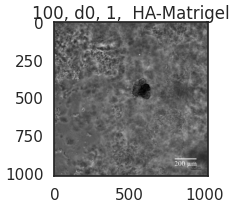

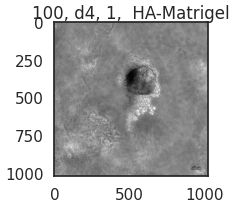

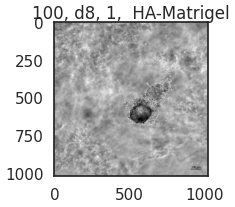

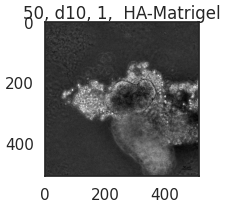

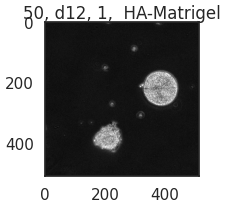

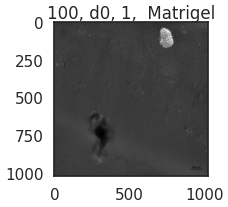

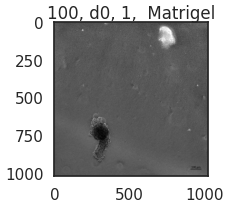

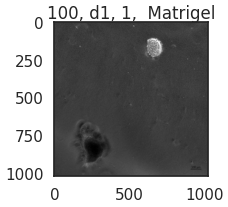

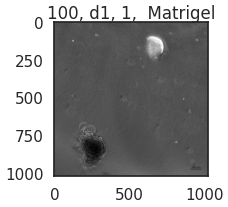

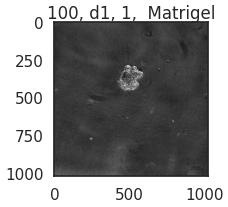

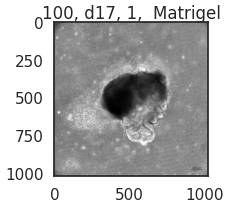

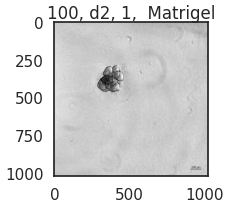

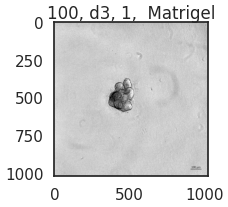

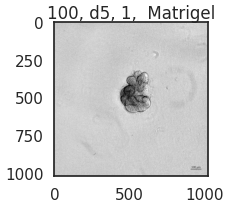

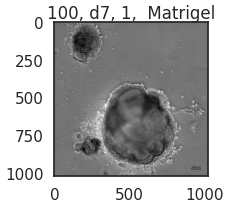

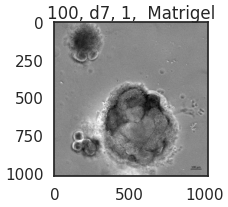

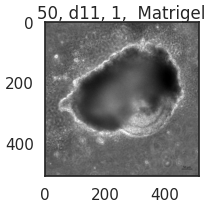

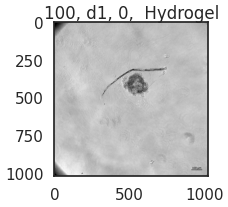

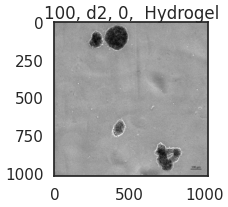

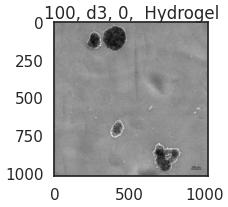

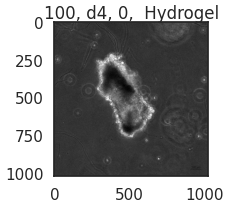

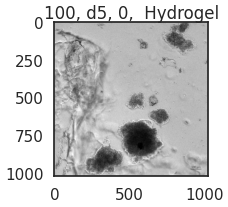

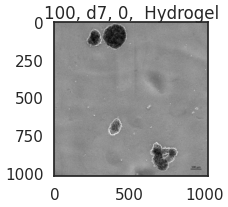

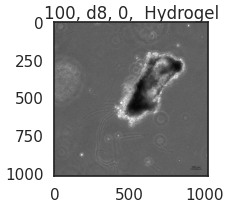

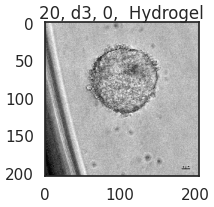

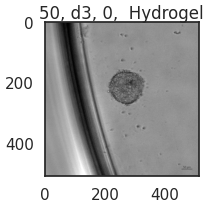

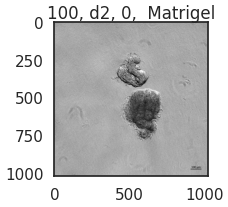

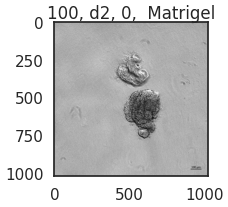

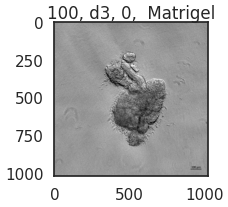

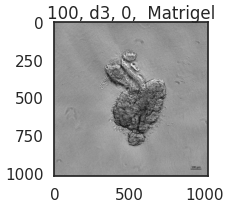

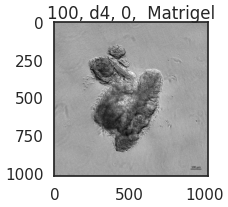

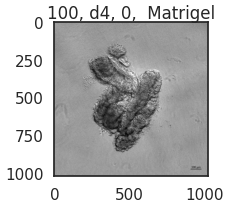

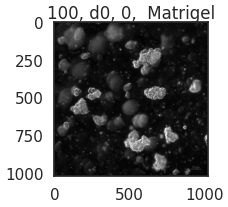

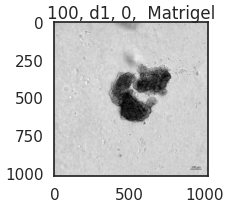

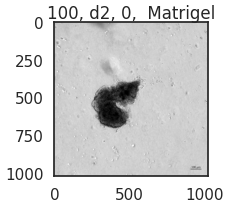

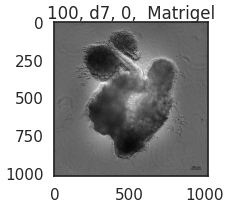

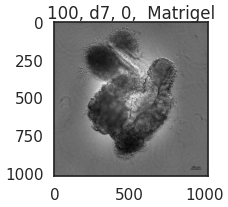

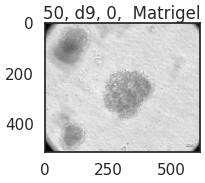

In [16]:
for im, label, day, condition, scale, filename in ds:
    plt.figure(figsize=(4, 4))
    plt.imshow(im, vmin=0, vmax=255)
    plt.title(f'{scale}, d{day}, {label},  {condition}')

### Detect organoids 

Save automatic detection boxes and masks in `automatic` 
and save manually corrected predictions in `manual`

In [6]:
samos = SAMOS()
samos.max_detections = 500

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [7]:
results_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/automatic')
results_dir.mkdir(exist_ok=True, parents=True)

In [8]:
ds = Imageset(split='train')
results_dir = results_dir / 'train'
results_dir.mkdir(exist_ok=True)
len(ds)

232

In [9]:
for im, label, day, condition, scale, filename in tqdm(ds):
    score = 0.95
    if (results_dir / f'score_{score}' / f'scores_{filename.stem}_score_{score}.npy').exists():
        continue
    contours, boxes, scores = samos.forward(im, patch_size=(1024,), min_diameter=10)
    for score in [0.8, 0.9, 0.95]:
        (results_dir / f'score_{score}').mkdir(exist_ok=True)
        contours, boxes, scores = samos.set_threshold(score)

        # Plot predictions with masks
        fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
        ax.imshow(im)
        for i in range(boxes.shape[0]):
            show_mask(contours[i], ax, random_color=True, linewidth=0.8)
        ax.axis(False)
        plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)
        fig.savefig(results_dir / f'score_{score}' / f'prediction_{filename.stem}_score_{score}.png', dpi=400, bbox_inches='tight')
        plt.close('all')
        
        # Plot boxes only
        fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
        ax.imshow(im)
        ax.axis(False)
        plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)
        fig.savefig(results_dir / f'score_{score}' / f'box_prediction_{filename.stem}_score_{score}.png', dpi=400, bbox_inches='tight')
        plt.close('all')

        # Save
        # Convert to GeoJSON-like dict
        features = [
            {
                "type": "Feature",
                "geometry": mapping(poly),
                "properties": {}
            }
            for poly in contours
        ]

        geojson = {
            "type": "FeatureCollection",
            "features": features
        }

        # Save to file
        # with open("polygons.geojson", "w") as f:
        with open(results_dir / f'score_{score}' / f'contours_{filename.stem}_score_{score}.geojson', 'w') as f:
            json.dump(geojson, f)

        np.save(results_dir / f'score_{score}' / f'boxes_{filename.stem}_score_{score}.npy', boxes, allow_pickle=False)
        np.save(results_dir / f'score_{score}' / f'scores_{filename.stem}_score_{score}.npy', scores, allow_pickle=False)

    # break

 55%|██████████████████████████████████████████████████████████                                                | 127/232 [03:08<02:39,  1.52s/it]

torch.Size([1, 256, 64, 64])
patch 0
len(self.pred_scores) 300


 55%|██████████████████████████████████████████████████████████▍                                               | 128/232 [03:45<20:57, 12.09s/it]

torch.Size([1, 256, 64, 64])
patch 0
len(self.pred_scores) 300


 56%|██████████████████████████████████████████████████████████▉                                               | 129/232 [03:59<21:57, 12.79s/it]

...

 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████ | 230/232 [26:44<00:16,  8.07s/it]

torch.Size([1, 256, 64, 64])
patch 0
len(self.pred_scores) 300


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▌| 231/232 [26:57<00:09,  9.65s/it]

torch.Size([1, 256, 64, 64])
patch 0
len(self.pred_scores) 300


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 232/232 [27:11<00:00,  7.03s/it]


#### Manually correct detections

Selected prediction images were moved into the manual folder, those files which are missing don't have a threshold with perfect detection and require manually specifying the bounding boxes.

In [ ]:
filenames = Path('')
ds = ...
missing_filenames = ...

# Run prediction with 0.9 score threshold
im, label, ... = ds[...]

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


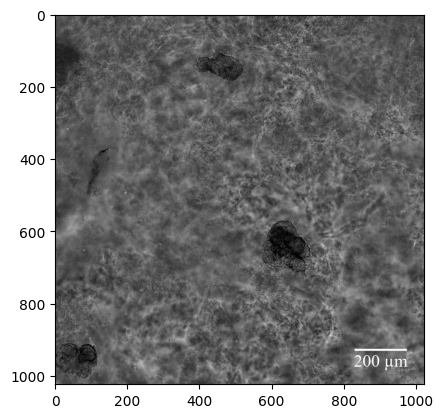

In [ ]:
plt.imshow(im)

In [ ]:
contours, boxes, scores = samos.forward(im, patch_size=(1024,), min_diameter=10)

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
len(self.pred_scores) 600


In [10]:
contours, boxes, scores = samos.set_threshold(0.95)

In [13]:
boxes

array([[ 99.66157532, 382.75717163, 184.57640076, 519.47943115],
       [561.99456787, 572.66625977, 720.35455322, 706.55114746]])

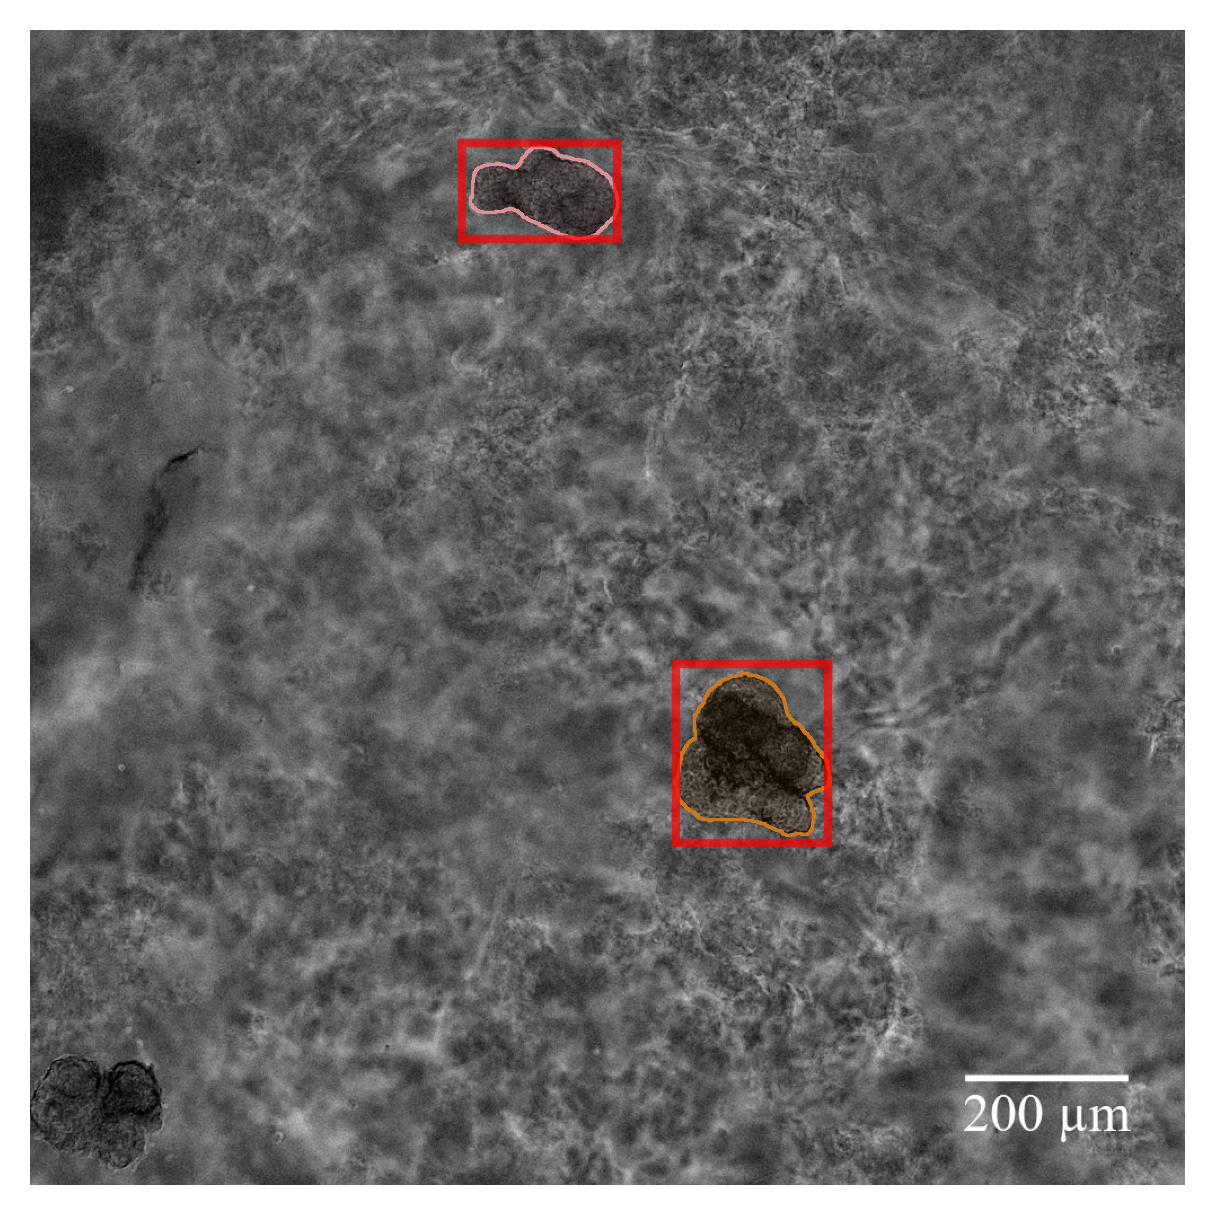

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

# Plot mask predictions
ax.imshow(im)
for i in range(boxes.shape[0]):
    show_mask(contours[i], ax, random_color=True, linewidth=0.8)
ax.axis(False)

plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)

# fig.savefig(results_dir / f'prediction_{file.stem}.png', dpi=400, bbox_inches='tight')

In [14]:
# Save manually corrected annotations

### Compute features

#### Segmentation-based shape features:

* `area`: Number of pixels in the object
* `perimeter`: Length of object boundary
* `eccentricity`: Ellipse shape (0: circle, 1: line)
* `solidity`: Area / convex hull area
* `extent`: Area / bounding box area
* `aspect_ratio`: Major axis / minor axis length
* `equivalent_diameter`: Diameter of a circle with same area
* `compactness`: (Perimeter²) / Area (optional)
* `zernike_mask`: Zernike moments of the binary mask (using mahotas)

#### Intensity-based shape features:
* Intensity-based skimage features
* `zernike`: Zernike moments with the background outside the mask set to zero and intensities inverted (using mahotas)

Computed using skimage.measure.regionprops

#### Texture features:
* `contrast`: Local intensity contrast
* `homogeneity`: Uniformity of textures
* `correlation`: Pixel intensity correlation
* `ASM / energy`: Angular Second Moment (uniformity)
* `entropy`: Randomness of intensity distribution

These are computed from the GLCM at multiple distances (1, 3, 5, 10), with 4 directions as neighbours (matrices added before normalization), and with the background set to 0 and all correlation with 0 pixels excluded from computing features (hence ignoring the texture outside the segmented area.)

In [ ]:
def parse_filename_score(filepath: Path):
    filename, score = filepath.stem.split('_score_')
    filename = filename.replace('box_prediction_', '')
    score = float(score)
    return filename, score

all_crops = dict()

In [35]:
split = 'split_4'
split_legacy = 'test' if (split=='split_4') else 'train'
results_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/automatic/') / split_legacy
manual_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/manual/') / split_legacy
correct_detections = {
    f: s for f, s in map(parse_filename_score, sorted(list(manual_dir.glob('*.png'))))
}


ds = Imageset(split=split)
correct_detections

{'scale_100_um_A5 d2-4-Draw Scale Bar Annotation-99-Image Export-85': 0.8,
 'scale_100_um_H8 d1-4-Draw Scale Bar Annotation-121-Image Export-62': 0.8,
 'scale_100_um_d0-1-Draw Scale Bar Annotation-73-Image Export-06': 0.8,
 'scale_100_um_d0-2-Draw Scale Bar Annotation-01-Image Export-07': 0.8,
 'scale_100_um_d1-1-Draw Scale Bar Annotation-69-Image Export-17': 0.8,
 'scale_100_um_d1-3-Draw Scale Bar Annotation-67-Image Export-19': 0.8,
 'scale_100_um_d2 3-Draw Scale Bar Annotation-139-Image Export-158': 0.8,
 'scale_100_um_d2 well1-1-Draw Scale Bar Annotation-85-Image Export-162': 0.8,
 'scale_100_um_d2-3-Draw Scale Bar Annotation-63-Image Export-31': 0.8,
 'scale_100_um_d3 well1-1-Draw Scale Bar Annotation-59-Image Export-02': 0.8,
 'scale_100_um_d3-3-Draw Scale Bar Annotation-59-Image Export-42': 0.95,
 'scale_100_um_d4-1-Draw Scale Bar Annotation-28-Image Export-46': 0.8,
 'scale_100_um_d5-3-Draw Scale Bar Annotation-46-Image Export-55': 0.8,
 'scale_100_um_d7 well1-2-Draw Scale Bar 

In [36]:
## Only run this cell once to create images for manual labeling

# import shutil


# for_manual_correction = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/to_correct/') / split
# for_manual_correction.mkdir(exist_ok=True, parents=True)

# for_manual_correction_2 = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/to_correct_preprocessed/') / split
# for_manual_correction_2.mkdir(exist_ok=True, parents=True)

# for im, label, day, condition, scale, filename in tqdm(ds):
#     if filename.stem not in correct_detections:
#         # Requires manual correction. Copy image to the manual correction folders
#         outfile = for_manual_correction / filename.name

#         print('filename', filename)
#         print('outfile', outfile)
#         if not outfile.exists():
#             shutil.copyfile(filename, outfile)
#         cv2.imwrite(for_manual_correction_2 / f'{filename.stem}.png', im)

In [37]:
def crop_organoid(im, mask):
    # Find the center of mass of the mask
    coords = np.nonzero(mask)
    center = np.array([np.mean(coords[0]), np.mean(coords[1])], dtype=int)

    # Crop a fixed size square around the center coord
    size = 200
    left = center[1] - size
    right = center[1] + size
    top = center[0] - size
    bottom = center[0] + size
    # Ensure the crop is within the image bounds
    left = max(0, left)
    right = min(im.shape[1], right)
    top = max(0, top)
    bottom = min(im.shape[0], bottom)

    return im[top:bottom, left:right]

In [38]:
from skimage.measure import regionprops, regionprops_table
from skimage.feature import graycomatrix, graycoprops
from copy import copy

data = []
crops = []
for im, label, day, condition, scale, filename in tqdm(ds):
    if filename.stem not in correct_detections:
        continue
    
    score = correct_detections[filename.stem]

    with open(results_dir / f'score_{score}' / f'contours_{filename.stem}_score_{score}.geojson', 'r') as f:
        geojson = json.load(f)

    contours = [
        shapely.from_geojson(geometry=json.dumps(c['geometry'])) for c in geojson['features']
    ]

    for contour in contours:
        mask = pp.contour_to_mask(contour, im.shape[:2])

        # Invert and normalize intensity
        intensity = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).astype(float)
        texture_im = np.clip(1.0 + intensity / 255.0 * 254.0, 1, 255).astype(np.uint8)
        texture_im[~mask] = 0

        crops.append(crop_organoid(texture_im, mask))

        min_intensity = intensity[mask].min()
        max_intensity = intensity[mask].max()
        intensity_neg = (intensity - max_intensity) / np.minimum(min_intensity - max_intensity, -1)
        intensity_pos = (intensity - min_intensity) / np.maximum(max_intensity - min_intensity, 1)
        intensity_neg[np.logical_not(mask)] = 0.0
        intensity_pos[np.logical_not(mask)] = 0.0
        intensity_neg = np.clip(intensity_neg, 0.0, 1.0)
        intensity_pos = np.clip(intensity_pos, 0.0, 1.0)

        # Intensity and mask-based features
        props_1 = regionprops(label_image=mask.astype(np.uint8), intensity_image=texture_im)[0]

        features = {
            "shape_area": props_1.area,
            "shape_area_bbox": props_1.area_bbox,
            "shape_area_convex": props_1.area_convex,
            "shape_area_filled": props_1.area_filled,
            "shape_axis_major_length": props_1.axis_major_length,
            "shape_axis_minor_length": props_1.axis_minor_length,
            "shape_eccentricity": props_1.eccentricity,
            "shape_equivalent_diameter_area": props_1.equivalent_diameter_area,
            "shape_extent": props_1.extent,
            "shape_feret_diameter_max": props_1.feret_diameter_max,
            "shape_perimeter": props_1.perimeter,
            "shape_perimeter_crofton": props_1.perimeter_crofton,
            "shape_solidity": props_1.solidity,
            "shape_aspect_ratio": props_1.axis_major_length / props_1.axis_minor_length,
            "intensity_max": props_1.intensity_max,
            "intensity_mean": props_1.intensity_mean,
            "intensity_min": props_1.intensity_min,
            "intensity_std": props_1.intensity_std,
        }

        for i, m in enumerate(props_1.moments_hu):
            features[f"intensity_moments_hu_{i}"] = m
        for i, m in enumerate(props_1.moments_weighted_hu):
            features[f"intensity_moments_weighted_hu_{i}"] = m
            
        # Zernike moments
        

        # Texture features
        distances = [1, 5, 20]
        glcm = graycomatrix(
            texture_im, distances=distances, angles=[0, 0.5*np.pi, 1.0*np.pi, 1.5*np.pi], levels=256, symmetric=True, normed=False
        )
        glcm = np.sum(glcm, axis=-1, keepdims=True)
        glcm = glcm[1:, 1:, :, :]
        glcm = glcm.astype(float) / np.sum(glcm, axis=(0, 1), keepdims=True)
        contrast = graycoprops(glcm, 'contrast')
        dissimilarity = graycoprops(glcm, 'dissimilarity')
        homogeneity = graycoprops(glcm, 'homogeneity')
        ASM = graycoprops(glcm, 'ASM')
        energy = graycoprops(glcm, 'energy')
        correlation = graycoprops(glcm, 'correlation')

        for j, dist in enumerate(distances):
            features[f'texture_contrast_d{dist}'] = contrast[j]
            features[f'texture_dissimilarity_d{dist}'] = dissimilarity[j]
            features[f'texture_homogeneity_d{dist}'] = homogeneity[j]
            features[f'texture_ASM_d{dist}'] = ASM[j]
            features[f'texture_energy_d{dist}'] = energy[j]
            features[f'texture_correlation_d{dist}'] = correlation[j]


        features['label'] = label
        features['day'] = day
        features['condition'] = condition
        features['scale'] = scale
        features['filename'] = filename

        data.append(features)
        # plt.figure()
        # plt.imshow(im)
        # plt.figure()
        # plt.imshow(mask, vmax=1)
        # plt.figure()
        # plt.imshow(texture_im, vmin=0, vmax=255)
        # plt.figure()
        # plt.imshow(intensity_neg, vmin=0.0, vmax=1.0)
        # plt.figure()
        # plt.imshow(intensity_pos, vmin=0.0, vmax=1.0)
        # print(features)
    #     break
    # break
data = pd.concat([pd.DataFrame(df) for df in data], axis=0, ignore_index=True)
all_crops[split] = copy(crops)
data

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:59<00:00,  1.60s/it]


,shape_area,shape_area_bbox,shape_area_convex,shape_area_filled,shape_axis_major_length,shape_axis_minor_length,shape_eccentricity,shape_equivalent_diameter_area,shape_extent,shape_feret_diameter_max,...,texture_dissimilarity_d20,texture_homogeneity_d20,texture_ASM_d20,texture_energy_d20,texture_correlation_d20,label,day,condition,scale,filename
0,13662.0,18060.0,14484.0,13662.0,143.326509,124.714323,0.492802,131.890101,0.756478,151.644321,...,28.233338,0.047684,0.000398,0.019955,0.370787,1,0,HA-Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
1,33181.0,43659.0,35913.0,33187.0,225.493709,189.051585,0.545071,205.541629,0.760004,241.118228,...,31.263434,0.039282,0.000114,0.010671,0.656784,1,4,HA-Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
2,14095.0,19388.0,14315.0,14095.0,144.724369,124.596090,0.508741,133.963844,0.726996,150.442680,...,45.521634,0.026848,0.000113,0.010630,0.305060,1,8,HA-Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
3,14570.0,19205.0,15343.0,14570.0,174.135950,108.520634,0.782067,136.202423,0.758657,172.956642,...,34.344860,0.032632,0.000103,0.010143,0.293073,1,10,HA-Matrigel,50,/ictstr01/groups/peng/datasets/lion/lung_organ...
4,9075.0,11830.0,9420.0,9075.0,136.381587,86.321408,0.774201,107.492553,0.767117,135.074054,...,62.429697,0.029073,0.000351,0.018722,0.041889,1,0,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
5,10044.0,12500.0,10262.0,10044.0,128.516259,100.081576,0.627339,113.085888,0.803520,127.882759,...,56.202727,0.031160,0.000339,0.018425,0.149412,1,1,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
6,19009.0,29412.0,20985.0,19009.0,179.477507,140.382760,0.623059,155.573168,0.646301,180.579622,...,72.971143,0.018565,0.000086,0.009296,0.084325,1,1,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
7,21414.0,30102.0,22935.0,21414.0,190.459101,148.293834,0.627505,165.121627,0.711381,196.735864,...,61.316151,0.022313,0.000075,0.008669,0.305700,1,2,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
8,25628.0,37400.0,27908.0,25628.0,219.405753,157.632490,0.695577,180.639373,0.685241,222.766694,...,57.306863,0.022592,0.000060,0.007776,0.314893,1,3,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...
9,40112.0,55216.0,43246.0,40112.0,282.607295,189.385739,0.742237,225.991559,0.726456,282.846248,...,52.570455,0.021060,0.000042,0.006517,0.359873,1,5,Matrigel,100,/ictstr01/groups/peng/datasets/lion/lung_organ...


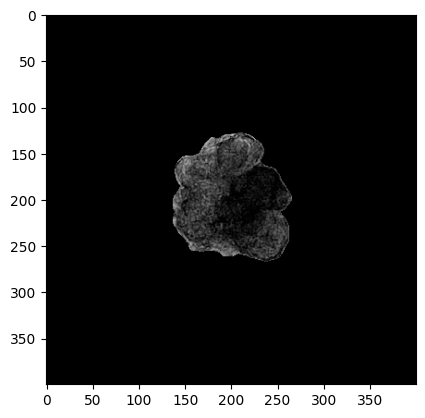

In [39]:
plt.imshow(crops[0], vmin=0, vmax=255, cmap='gray')

In [ ]:
(results_dir.parent / 'cv').mkdir(exist_ok=True)
data.to_csv(results_dir.parent / 'cv' / f"raw_features_{split}.csv", index=False)

Datasplits

1.
good: HA-Matrigel d0-d8
bad: hydrogel contains well1

2.
good: HA-Matrigel d10-d12
bad: hydrogel does not contain well1

3.
good: Matrigel contains "well"
bad: in matrigel contains "glass" or "plate" 

4.
good: Matrigel does not contain "well"
bad: in matrigel does not contain "glass" or "plate"


### Visualizing simple feature relationships

In [ ]:
results_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/automatic')
data_train = pd.concat([
    pd.read_csv(results_dir / 'cv' / 'raw_features_split_0.csv'),
    pd.read_csv(results_dir / 'cv' / 'raw_features_split_1.csv'),
    pd.read_csv(results_dir / 'cv' / 'raw_features_split_2.csv'),
    pd.read_csv(results_dir / 'cv' / 'raw_features_split_3.csv'),
], axis=0, ignore_index=True)
data_test = pd.read_csv(results_dir / 'cv' / 'raw_features_split_4.csv')

In [42]:
len(data_test)

28

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, 'Correlation')

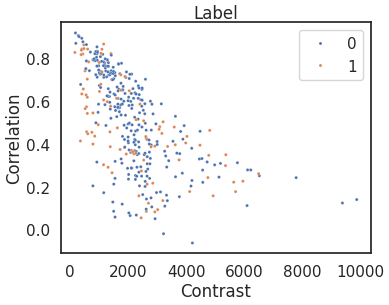

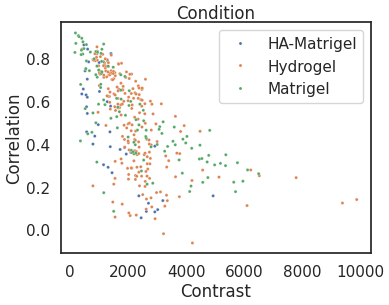

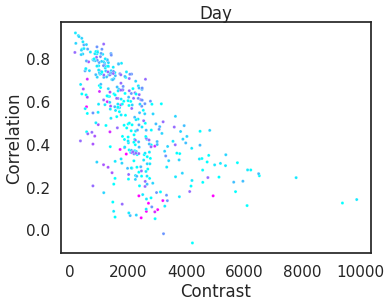

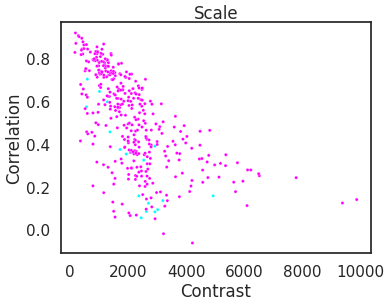

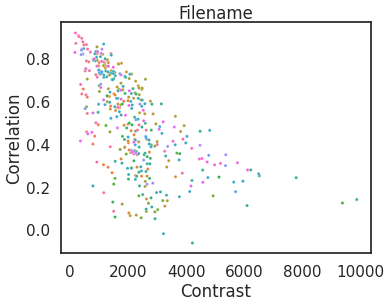

In [43]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn import preprocessing
from sklearn.decomposition import PCA
from tqdm import tqdm


sns.set_theme(style='white', context='poster', rc={'figure.figsize': (8, 6), 
                                                   'figure.dpi':50})


x_var = 'texture_contrast_d5'
y_var = 'texture_correlation_d5'  # 'shape_area'
data = data_train

name_x = 'Contrast'
name_y = 'Correlation'

x = data[x_var].values
y = data[y_var].values

##### Plots colored by ... #####

# Training data: label
fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=x, 
                y=y, 
                hue=data['label'].values.tolist(), 
                s=20, ax=ax, legend=True)
plt.title("Label")
plt.xlabel(name_x)
plt.ylabel(name_y)
# plt.savefig(plots_folder / f'UMAP_{locations[loc_idx]}_{id_str}.png', bbox_inches='tight')

# Training data: condition
fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=x, 
                y=y, 
                hue=data['condition'].values.tolist(), 
                s=20, ax=ax, legend=True)
plt.title("Condition")
plt.xlabel(name_x)
plt.ylabel(name_y)

# Training data: day
fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=x, 
                y=y, 
                c=data['day'].values.tolist(), 
                s=20, ax=ax, cmap='cool', legend=True)
plt.title("Day")
plt.xlabel(name_x)
plt.ylabel(name_y)

# Training data: scale
fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=x, 
                y=y, 
                c=data['scale'].values.tolist(), 
                s=20, ax=ax, cmap='cool', legend=True)
plt.title("Scale")
plt.xlabel(name_x)
plt.ylabel(name_y)

# Training data: filename
fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=x, 
                y=y, 
                hue=data['filename'].values.tolist(), 
                s=20, ax=ax, legend=False)
plt.title("Filename")
plt.xlabel(name_x)
plt.ylabel(name_y)


### Manually select features & feature normalization

In [ ]:
from sklearn.preprocessing import StandardScaler

# selected_columns = ['shape_area', 'shape_equivalent_diameter_area', 'shape_eccentricity', 'shape_extent', 'shape_aspect_ratio']
# selected_columns = [c for c in data_train.columns if c.startswith('shape_')]
# selected_columns = [c for c in data_train.columns if c.startswith('intensity_')]
# selected_columns = [c for c in data_train.columns if c.startswith('texture_')]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('texture_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('shape_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('shape_'))]
selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_') or c.startswith('shape_'))]

print(len(selected_columns))

X_train = data_train.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
y_train = data_train['label'].values

X_test = data_test.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
y_test = data_test['label'].values

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_test

50


array([[-0.46544975, -0.52037994, -0.47439188, ...,  0.13200275,
         0.70996406,  0.59808746],
       [ 0.37991281,  0.15507619,  0.35229886, ..., -0.15220465,
        -0.18444346,  1.99560673],
       [-0.44669664, -0.48533928, -0.48091159, ..., -0.15307643,
        -0.18838799,  0.27691278],
       ...,
       [ 0.24132169,  0.28861592,  0.23486703, ..., -0.22537229,
        -0.59808915, -0.47186463],
       [ 1.69739472,  1.40144698,  1.55204011, ..., -0.20419357,
        -0.45476807,  0.84466094],
       [ 1.91927045,  1.69657478,  1.80769738, ..., -0.13445561,
        -0.10719107,  1.61029301]])

### Removing correlated features

In [62]:
import pandas as pd
import numpy as np

def remove_highly_correlated_features(X, threshold=0.9):
    """
    Removes features from a DataFrame that have a correlation coefficient
    higher than the given threshold.
    
    Parameters:
        X (np.ndarray): Feature matrix
        threshold (float): Correlation threshold to remove features
    
    Returns:
        pd.DataFrame: Reduced DataFrame with low-correlated features
    """
    # Compute correlation matrix
    corr_matrix = np.corrcoef(X, rowvar=False,)
    
    # Get upper triangle of correlation matrix
    upper = np.triu(corr_matrix, k=1)
    # print(upper)
    
    # Find features with correlation greater than threshold
    to_drop = np.any(upper > threshold, axis=0)
    
    print(f"Removing {to_drop.sum()} of {X.shape[1]} features due to correlation > {threshold}")
    
    # Drop those features
    X_filtered = X[:, ~to_drop]
    assert X_filtered.shape[0] == X.shape[0], X_filtered.shape
    return X_filtered, to_drop

X_train, to_drop = remove_highly_correlated_features(X_train, threshold=0.9)
X_test = X_test[:, ~to_drop]

Removing 0 of 13 features due to correlation > 0.9


### UMAP visualizations

* condition
* filename
* day
* label


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting UMAP with 15 neighbors, euclidean metric, 0.1 min_dist
UMAP finished


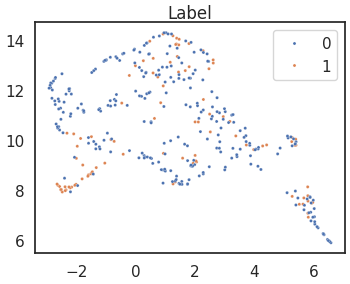

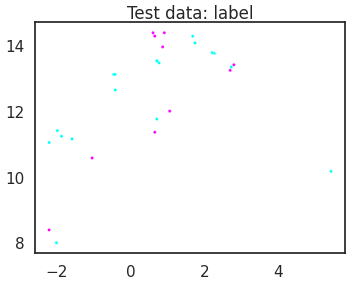

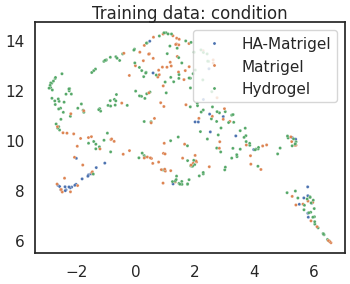

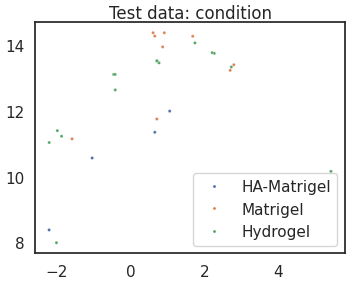

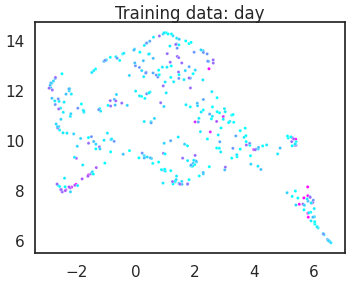

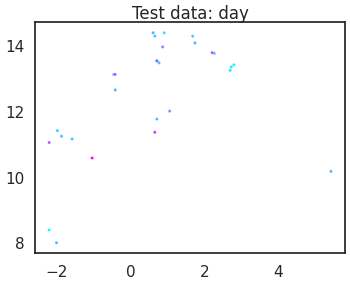

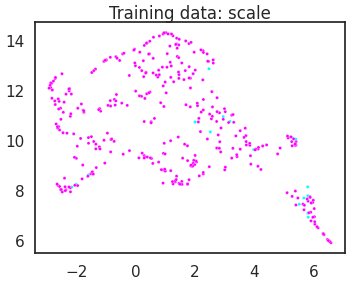

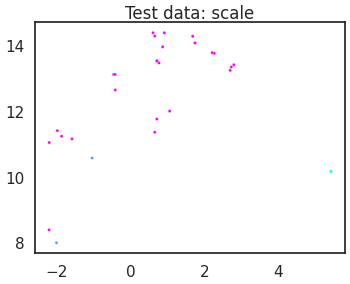

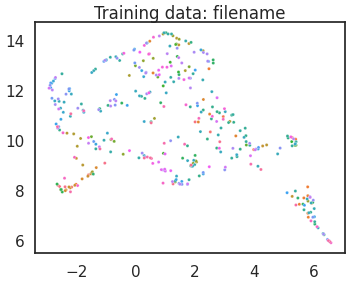

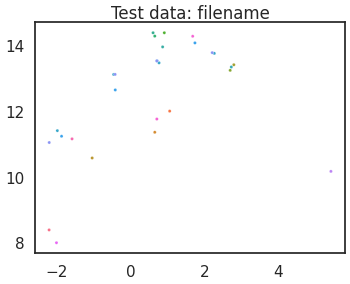

In [16]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn import preprocessing
from sklearn.decomposition import PCA
from tqdm import tqdm


sns.set_theme(style='white', context='poster', rc={'figure.figsize': (8, 6), 
                                                   'figure.dpi':50})



n_samples = None  # 20

pca = False
pca_n_components = 10


X = X_train
y = y_train

if pca and (X_train.shape[1] > pca_n_components):
    # Scale each embedding dimension to zero mean, unit variance.
    scaler = preprocessing.StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_test = scaler.transform(X_test)

    # Initial dimensionality reduction with PCA
    pca = PCA(n_components=pca_n_components)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_test = pca.transform(X_scaled_test)
else:
    X_pca = X
    X_pca_test = X_test
    
# UMAP
for n_neighbors in [5]:
    for metric in ['euclidean']:
        for min_dist in [0.01]:
            # reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric)
            reducer = umap.UMAP()
            print(f'Starting UMAP with {reducer.n_neighbors} neighbors, {reducer.metric} metric, {reducer.min_dist} min_dist')
            low_dim_embedding = reducer.fit_transform(X_pca)

            low_dim_test = reducer.transform(X_pca_test)

            id_str = f'{metric}_n{n_neighbors}_d{min_dist}_pca{pca}'

            ##### Plots colored by ... #####

            # Training data: label
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_embedding[:, 0], 
                            y=low_dim_embedding[:, 1], 
                            hue=y.tolist(), 
                            s=20, ax=ax, legend=True)
            plt.title(f"Label")
            # plt.savefig(plots_folder / f'UMAP_{locations[loc_idx]}_{id_str}.png', bbox_inches='tight')
            
            # Test data: label
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_test[:, 0], 
                            y=low_dim_test[:, 1], 
                            c=y_test, 
                            s=20, ax=ax, cmap='cool', legend=True)
            plt.title(f"Test data: label")

            # Training data: condition
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_embedding[:, 0], 
                            y=low_dim_embedding[:, 1], 
                            hue=data_train['condition'].values.tolist(), 
                            s=20, ax=ax, legend=True)
            plt.title(f"Training data: condition")
            
            # Test data: condition
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_test[:, 0], 
                            y=low_dim_test[:, 1], 
                            hue=data_test['condition'].values.tolist(), 
                            s=20, ax=ax, legend=True)
            plt.title(f"Test data: condition")

            # Training data: day
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_embedding[:, 0], 
                            y=low_dim_embedding[:, 1], 
                            c=data_train['day'].values.tolist(), 
                            s=20, ax=ax, cmap='cool', legend=True)
            plt.title(f"Training data: day")
            
            # Test data: day
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_test[:, 0], 
                            y=low_dim_test[:, 1], 
                            c=data_test['day'].values.tolist(), 
                            s=20, ax=ax, cmap='cool', legend=True)
            plt.title(f"Test data: day")

            # Training data: scale
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_embedding[:, 0], 
                            y=low_dim_embedding[:, 1], 
                            c=data_train['scale'].values.tolist(), 
                            s=20, ax=ax, cmap='cool', legend=True)
            plt.title(f"Training data: scale")
            
            # Test data: scale
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_test[:, 0], 
                            y=low_dim_test[:, 1], 
                            c=data_test['scale'].values.tolist(), 
                            s=20, ax=ax, cmap='cool', legend=True)
            plt.title(f"Test data: scale")

            # Training data: filename
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_embedding[:, 0], 
                            y=low_dim_embedding[:, 1], 
                            hue=data_train['filename'].values.tolist(), 
                            s=20, ax=ax, legend=False)
            plt.title(f"Training data: filename")
            
            # Test data: filename
            fig, ax = plt.subplots(1, 1)
            sns.scatterplot(x=low_dim_test[:, 0], 
                            y=low_dim_test[:, 1], 
                            hue=data_test['filename'].values.tolist(), 
                            s=20, ax=ax, legend=False)
            plt.title(f"Test data: filename")

print('UMAP finished')

In [76]:
ids = iter(range(len(low_dim_embedding)))

/tmp/ipykernel_1436289/1814291399.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2, figsize=(14, 6))


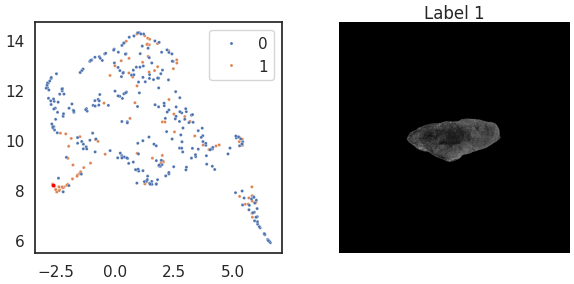

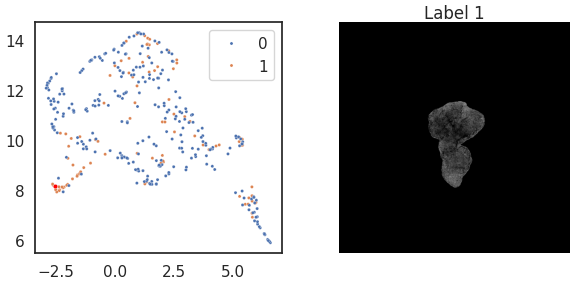

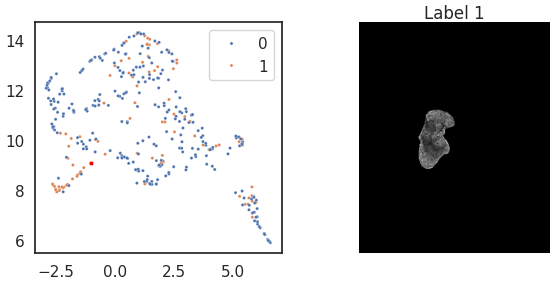

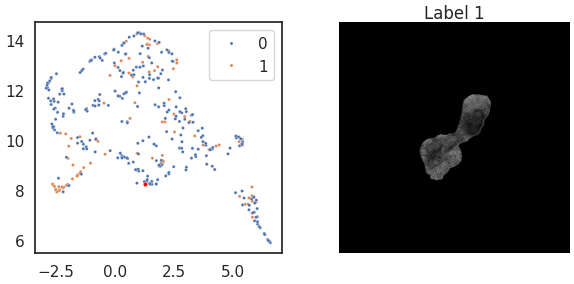

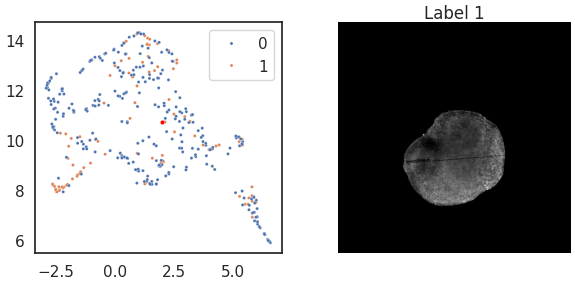

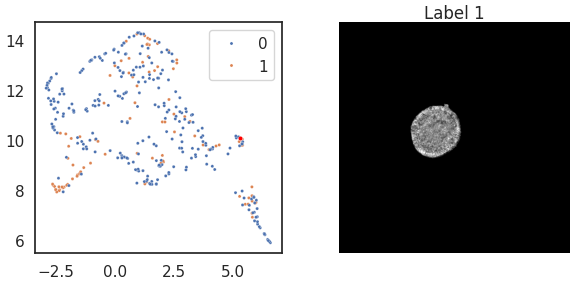

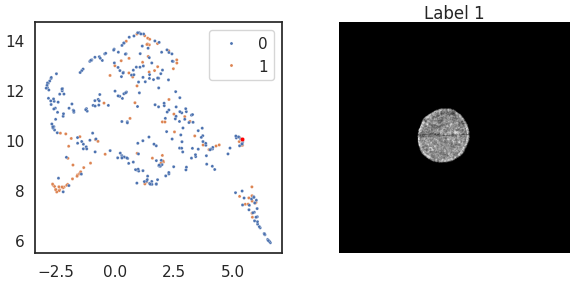

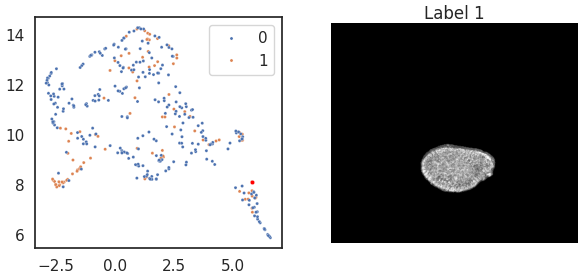

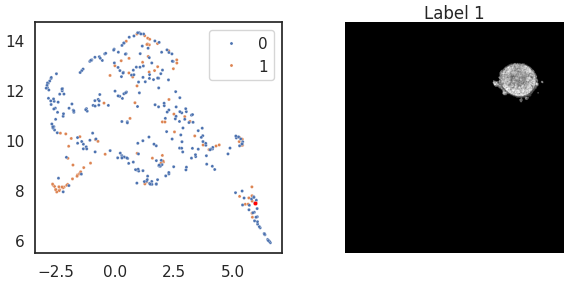

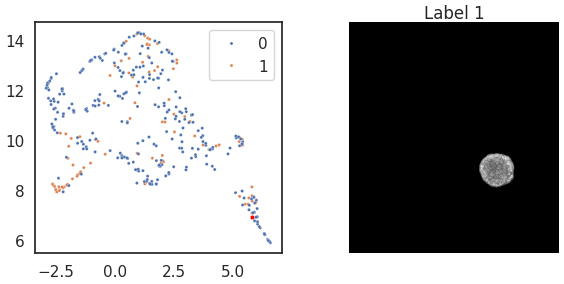

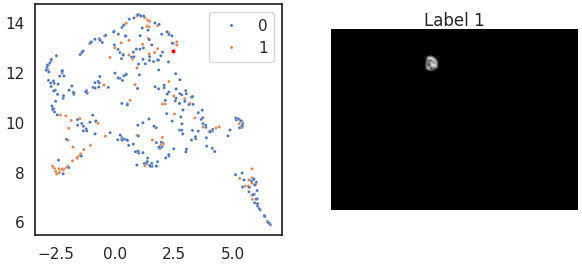

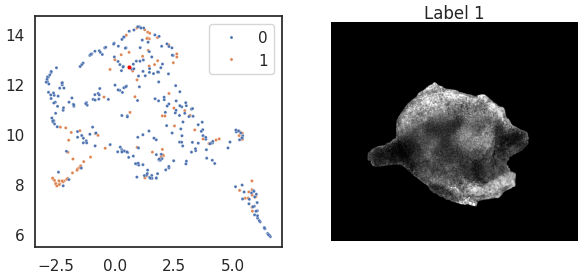

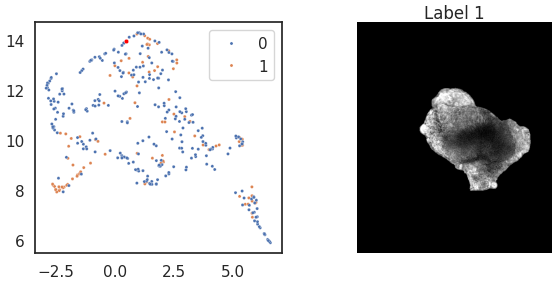

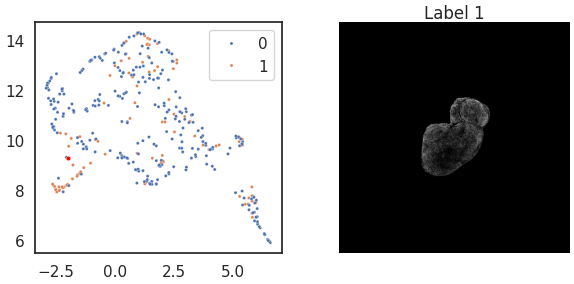

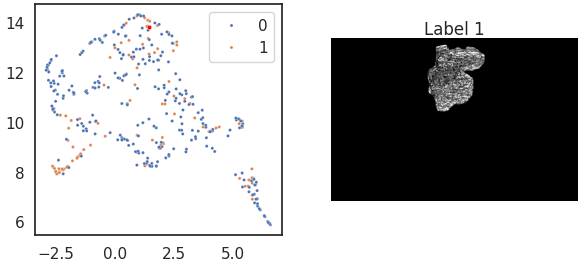

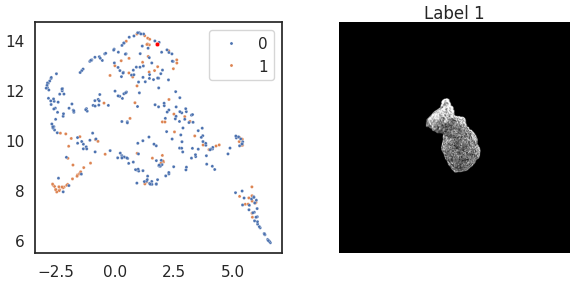

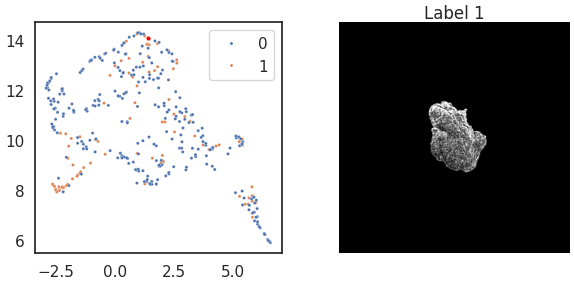

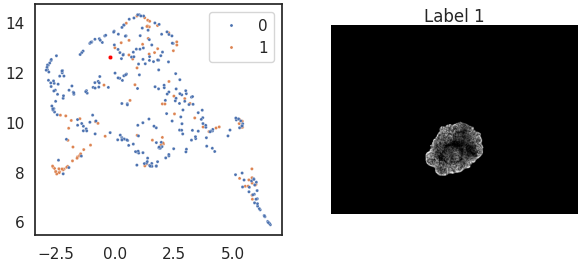

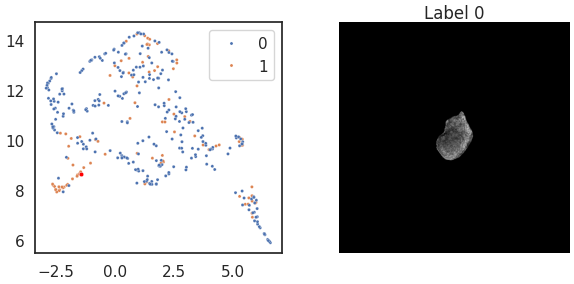

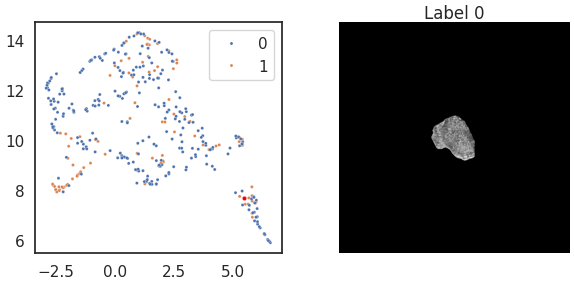

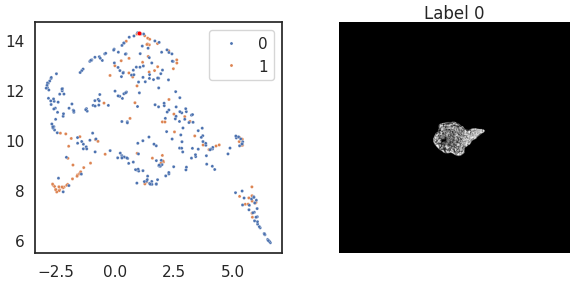

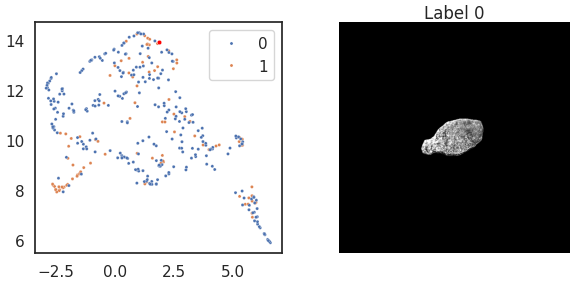

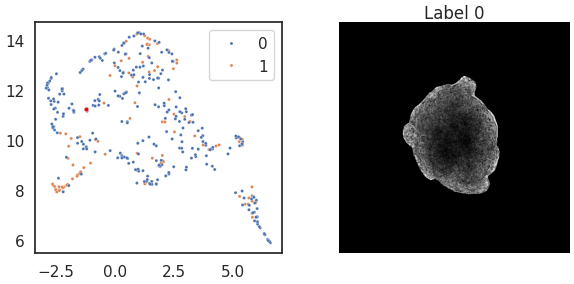

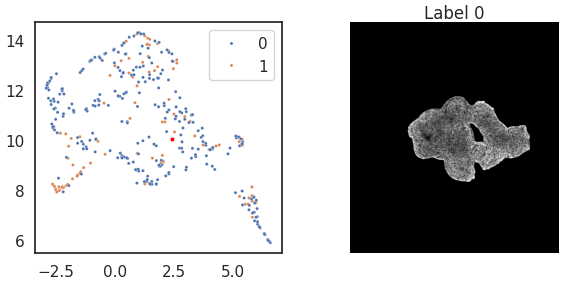

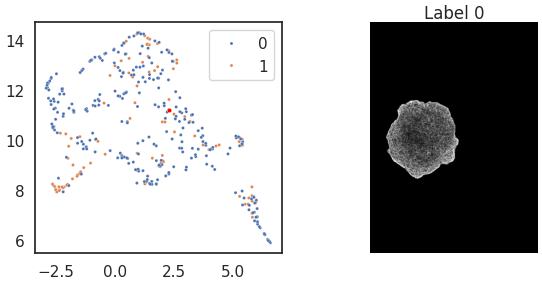

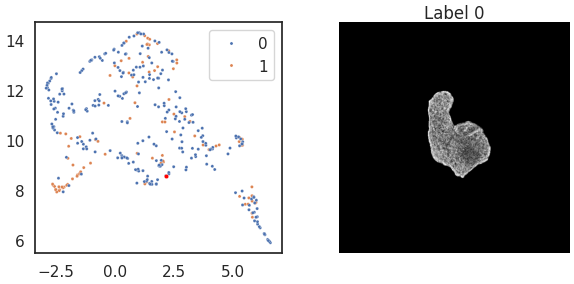

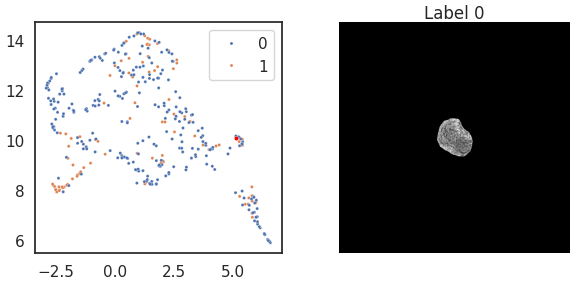

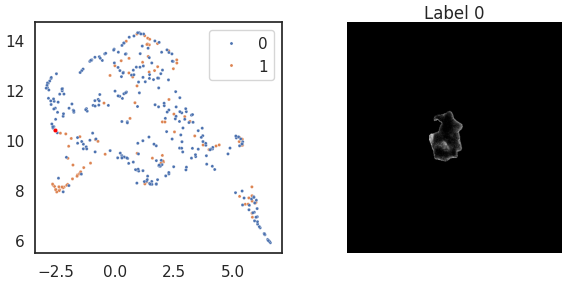

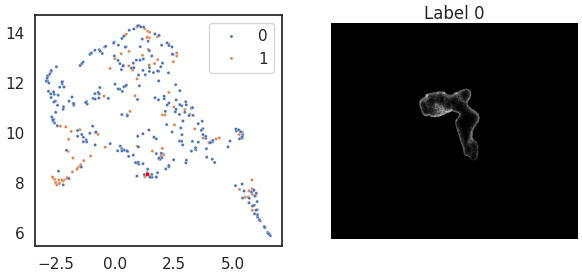

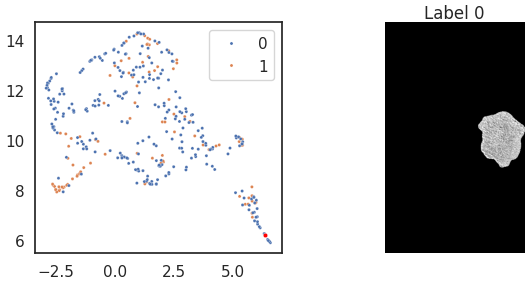

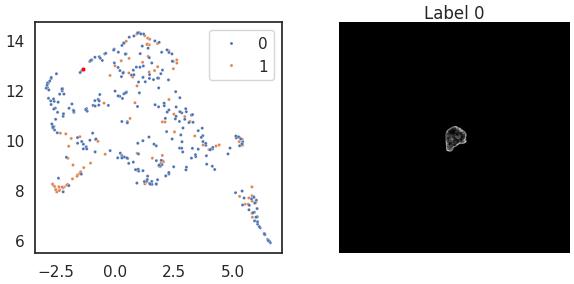

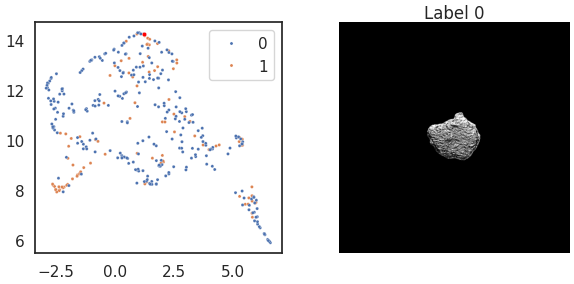

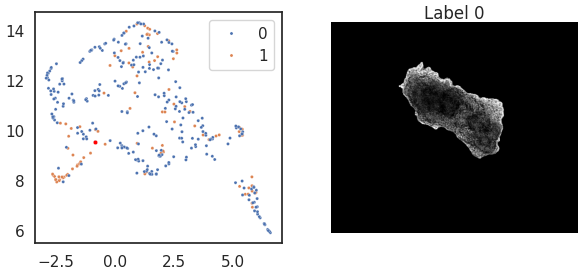

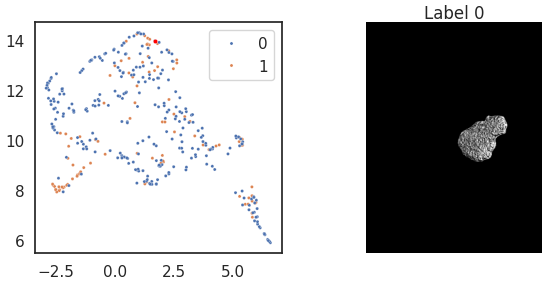

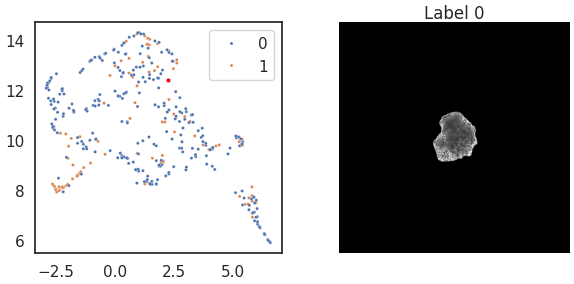

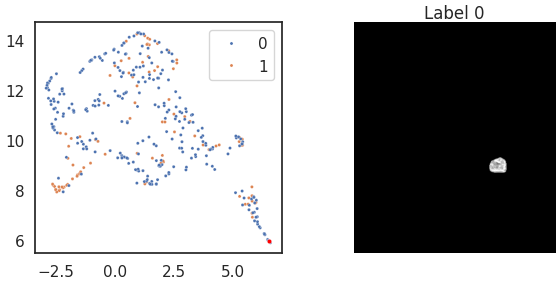

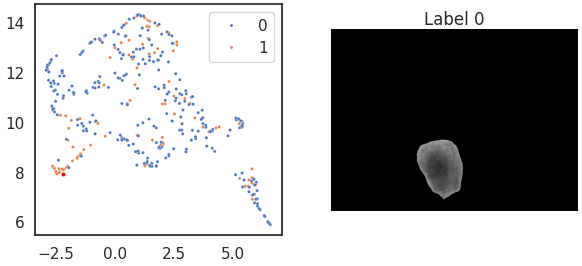

In [19]:
# selected_idx = next(ids)
# selected_idx = 365
# 0/4, 1, 2, 5, 9/12, 14, 15/17, 16, 23, 24, 38, 40/42, 47, 54
# 98, 99, 101/102, 103, 105, 108, 110, 113, 114, 125, 129, 140, 153, 156, 160, 165, 221, 365

for selected_idx in [0, 4, 1, 2, 5, 9, 12, 14, 15, 17, 16, 23, 24, 38, 40, 42, 47, 54,
                     98, 99, 101, 102, 103, 105, 108, 110, 113, 114, 125, 129, 140, 153, 156, 160, 165, 221, 365]:

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    sns.scatterplot(x=low_dim_embedding[:, 0], 
                    y=low_dim_embedding[:, 1], 
                    hue=y.tolist(), 
                    s=20, ax=axs[0], legend=True)
    sns.scatterplot(x=low_dim_embedding[selected_idx:selected_idx+1, 0], 
                    y=low_dim_embedding[selected_idx:selected_idx+1, 1], 
                    color = 'red',
                    s=40, ax=axs[0])
    plt.title(f"Label {y[selected_idx]}")
    axs[1].imshow(crops[selected_idx], vmin=0, vmax=255, cmap='gray')
    axs[1].axis(False)
    # print('idx', selected_idx, 'label', y[selected_idx:selected_idx+1])

In [315]:
np.nonzero((low_dim_embedding[:, 1] < 5) & (y==0))

(array([347, 351, 365]),)

### Machine learning-based outcome prediction

In [46]:
y_train.mean(), y_test.mean()

(0.2572944297082228, 0.35714285714285715)

In [47]:
X_test.shape, y_test.shape, X_train.shape, y_train.shape

((28, 27), (28,), (377, 27), (377,))

In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

classifiers = [
    KNeighborsClassifier(1),
    KNeighborsClassifier(3),
    KNeighborsClassifier(5),
    KNeighborsClassifier(10),
] + [SVC(C=c, random_state=42) for c in [0.01, 0.1, 0.25, 0.5, 1.0, 2.0, 10.0, 100.0, 1000.0, 10000.0]
] + [GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42)
] + [RandomForestClassifier(max_depth=5, 
                            n_estimators=c, 
                            max_features='sqrt', 
                            random_state=42) for c in [5, 10, 20, 50, 100, 200, 1000]
] + [MLPClassifier(alpha=alpha, max_iter=1000, random_state=42) for alpha in [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 2.0, 10.0, 100.0]
] + [
    AdaBoostClassifier(algorithm='SAMME', random_state=42)
]

# Feature selection + PCA + kNN pipeline
# for k in range(1, 20):
for c in classifiers:
    pipe = Pipeline([
        # ('select', SelectKBest(score_func=f_classif, k=k)),
        # ('pca', PCA(n_components=k)),
        (str(c), c)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=30)
    # print(f"Mean accuracy k {k}: {scores.mean():0.3f}")
    print(f"Mean accuracy {str(c)}: {scores.mean():0.3f}")

Mean accuracy KNeighborsClassifier(n_neighbors=1): 0.827
Mean accuracy KNeighborsClassifier(n_neighbors=3): 0.803
Mean accuracy KNeighborsClassifier(): 0.793
Mean accuracy KNeighborsClassifier(n_neighbors=10): 0.777
Mean accuracy SVC(C=0.01, random_state=42): 0.743
Mean accuracy SVC(C=0.1, random_state=42): 0.743
Mean accuracy SVC(C=0.25, random_state=42): 0.771
Mean accuracy SVC(C=0.5, random_state=42): 0.776
Mean accuracy SVC(random_state=42): 0.795
Mean accuracy SVC(C=2.0, random_state=42): 0.804
Mean accuracy SVC(C=10.0, random_state=42): 0.836
Mean accuracy SVC(C=100.0, random_state=42): 0.825
Mean accuracy SVC(C=1000.0, random_state=42): 0.825
Mean accuracy SVC(C=10000.0, random_state=42): 0.825
Mean accuracy GaussianProcessClassifier(kernel=1**2 * RBF(length_scale=1), random_state=42): 0.743
Mean accuracy RandomForestClassifier(max_depth=5, n_estimators=5, random_state=42): 0.821
Mean accuracy RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42): 0.816
Mean accu

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning:

Mean accuracy AdaBoostClassifier(random_state=42): 0.813


In [49]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

classifiers = [
    AdaBoostClassifier(algorithm='SAMME', random_state=42)
]

# Feature selection + PCA + kNN pipeline
# for k in range(1, 20):
for c in classifiers:
    pipe = Pipeline([
        # ('select', SelectKBest(score_func=f_classif, k=k)),
        # ('pca', PCA(n_components=k)),
        (str(c), c)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=30)
    # print(f"Mean accuracy k {k}: {scores.mean():0.3f}")
    print(f"Mean accuracy {str(c)}: {scores.mean():0.3f}")

Mean accuracy AdaBoostClassifier(algorithm='SAMME', random_state=42): 0.828


In [77]:
# Define final pipelines (one for each classifier type)
# Choose more regularization over less regularization if the score difference is only small

from sklearn.preprocessing import StandardScaler


results_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/automatic')
results_table = []

classifiers = [
    KNeighborsClassifier(n_neighbors=1),
    SVC(C=10.0, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    MLPClassifier(alpha=0.1, max_iter=1000, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42),
    AdaBoostClassifier(algorithm='SAMME', random_state=42)
]

shape_columns = [c for c in data_train.columns if c.startswith('shape_')]
intensity_columns = [c for c in data_train.columns if c.startswith('intensity_')]
texture_columns = [c for c in data_train.columns if c.startswith('texture_')]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('texture_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('shape_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('shape_'))]
all_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_') or c.startswith('shape_'))]


for split in range(5):
    data_train = pd.concat([
        pd.read_csv(results_dir / 'cv' / f'raw_features_split_{i}.csv') for i in range(5) if i != split
    ], axis=0, ignore_index=True)
    data_test = pd.read_csv(results_dir / 'cv' / f'raw_features_split_{split}.csv')
    
    for col_name, selected_columns in [('shape', shape_columns),
                                       ('intensity', intensity_columns),
                                       ('texture', texture_columns),
                                       ('all', all_columns)]:
        
        # Select subset of features
        # print(len(selected_columns))
        X_train = data_train.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
        y_train = data_train['label'].values

        X_test = data_test.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
        y_test = data_test['label'].values

        print('Mean test', np.mean(y_test))

        # Normalize features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # # Remove correlated features
        # X_train, to_drop = remove_highly_correlated_features(X_train, threshold=0.9)
        # X_test = X_test[:, ~to_drop]
        
        # Fit model
        for classifier in classifiers:
            pipe = Pipeline([
                # ('select', SelectKBest(score_func=f_classif, k=k)),
                # ('pca', PCA(n_components=5)),
                (str(classifier), classifier)
            ])
            test_accuracy = pipe.fit(X_train, y_train).score(X_test, y_test)
            print('Test accuracy:', test_accuracy)

            rng = np.random.default_rng(2025)
            acc_random = 0.0
            n_random_runs = 5
            for _ in range(n_random_runs):
                acc_random += pipe.fit(X_train, y_train).score(X_test, rng.permutation(y_test))
            acc_random = acc_random / n_random_runs
            print('Random accuracy:', acc_random)

            results_table.append([str(classifier), col_name, split, test_accuracy, acc_random])

results_table = pd.DataFrame(data=results_table, columns=['model', 'columns', 'fold', 'acc_test', 'acc_random'])
results_table.to_csv(results_dir / 'results_table_without_removing_corr_features.csv', index=False)
results_table

Mean test 0.18181818181818182
Test accuracy: 0.6776859504132231
Random accuracy: 0.6446280991735537
Test accuracy: 0.8016528925619835
Random accuracy: 0.7388429752066116


Test accuracy: 0.7603305785123967
Random accuracy: 0.7173553719008264
Test accuracy: 0.71900826446281
Random accuracy: 0.6859504132231405
Test accuracy: 0.7355371900826446
Random accuracy: 0.7256198347107439
Test accuracy: 0.7603305785123967
Random accuracy: 0.7305785123966941
Mean test 0.18181818181818182
Test accuracy: 0.8016528925619835
Random accuracy: 0.6495867768595043
Test accuracy: 0.8760330578512396
Random accuracy: 0.7305785123966942
Test accuracy: 0.859504132231405
Random accuracy: 0.7107438016528926


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Test accuracy: 0.8760330578512396


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Ma

...

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Test accuracy: 0.6071428571428571


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Ma

Random accuracy: 0.5071428571428571
Test accuracy: 0.6071428571428571
Random accuracy: 0.5928571428571429
Test accuracy: 0.6071428571428571
Random accuracy: 0.55
Mean test 0.35714285714285715
Test accuracy: 0.7142857142857143
Random accuracy: 0.5857142857142857
Test accuracy: 0.7142857142857143
Random accuracy: 0.48571428571428577
Test accuracy: 0.6428571428571429
Random accuracy: 0.6428571428571429
Test accuracy: 0.6428571428571429
Random accuracy: 0.5
Test accuracy: 0.5714285714285714
Random accuracy: 0.6571428571428573
Test accuracy: 0.75
Random accuracy: 0.5642857142857143


,model,columns,fold,acc_test,acc_random
0,KNeighborsClassifier(n_neighbors=1),shape,0,0.677686,0.644628
1,"SVC(C=10.0, random_state=42)",shape,0,0.801653,0.738843
2,GaussianProcessClassifier(kernel=1**2 * RBF(le...,shape,0,0.760331,0.717355
3,"MLPClassifier(alpha=0.1, max_iter=1000, random...",shape,0,0.719008,0.685950
4,"RandomForestClassifier(max_depth=5, n_estimato...",shape,0,0.735537,0.725620
...,...,...,...,...,...
115,"SVC(C=10.0, random_state=42)",all,4,0.714286,0.485714
116,GaussianProcessClassifier(kernel=1**2 * RBF(le...,all,4,0.642857,0.642857
117,"MLPClassifier(alpha=0.1, max_iter=1000, random...",all,4,0.642857,0.500000
118,"RandomForestClassifier(max_depth=5, n_estimato...",all,4,0.571429,0.657143


In [78]:
# Without removing correlated featues
results_table.groupby(['model', 'columns']).mean()

fold  acc_test  \
model                                              columns                     
AdaBoostClassifier(algorithm='SAMME', random_st... all         2.0  0.704168   
                                                   intensity   2.0  0.605929   
                                                   shape       2.0  0.632058   
                                                   texture     2.0  0.654917   
GaussianProcessClassifier(kernel=1**2 * RBF(len... all         2.0  0.654363   
                                                   intensity   2.0  0.708796   
                                                   shape       2.0  0.631427   
                                                   texture     2.0  0.647681   
KNeighborsClassifier(n_neighbors=1)                all         2.0  0.667495   
                                                   intensity   2.0  0.670259   
                                                   shape       2.0  0.612566   
                                                   texture     2.0  0.653756   
MLPClassifier(alpha=0.1, max_iter=1000, random_... all         2.0  0.685642   
                                                   intensity   2.0  0.743936   
                                                   shape       2.0  0.661269   
                                                   texture     2.0  0.660648   
RandomForestClassifier(max_depth=5, n_estimator... all         2.0  0.642171   
                                                   intensity   2.0  0.645015   
                                                   shape       2.0  0.628067   
                                                   texture     2.0  0.642503   
SVC(C=10.0, random_state=42)                       all         2.0  0.696944   
                                                   intensity   2.0  0.662849   
                                                   shape       2.0  0.620354   
                                                   texture     2.0  0.670390   

                                                              acc_random  
model                                              columns                
AdaBoostClassifier(algorithm='SAMME', random_st... all          0.606276  
                                                   intensity    0.569078  
                                                   shape        0.608455  
                                                   texture      0.606717  
GaussianProcessClassifier(kernel=1**2 * RBF(len... all          0.654363  
                                                   intensity    0.604535  
                                                   shape        0.621477  
                                                   texture      0.594304  
KNeighborsClassifier(n_neighbors=1)                all          0.588859  
                                                   intensity    0.557010  
                                                   shape        0.556996  
                                                   texture      0.599099  
MLPClassifier(alpha=0.1, max_iter=1000, random_... all          0.587933  
                                                   intensity    0.604218  
                                                   shape        0.600832  
                                                   texture      0.613784  
RandomForestClassifier(max_depth=5, n_estimator... all          0.631705  
                                                   intensity    0.617782  
                                                   shape        0.607745  
                                                   texture      0.605853  
SVC(C=10.0, random_state=42)                       all          0.592049  
                                                   intensity    0.614444  
                                                   shape        0.614407  
                                                   texture      0.587028

In [ ]:
# Define final pipelines (one for each classifier type)
# Choose more regularization over less regularization if the score difference is only small

from sklearn.preprocessing import StandardScaler


results_dir = Path('/ictstr01/groups/peng/datasets/lion/lung_organoids_hereon/data_2025_05_15/sorted_images/analysis/automatic')
results_table = []

classifiers = [
    KNeighborsClassifier(n_neighbors=1),
    SVC(C=10.0, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    MLPClassifier(alpha=0.1, max_iter=1000, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42),
    AdaBoostClassifier(algorithm='SAMME', random_state=42)
]

shape_columns = [c for c in data_train.columns if c.startswith('shape_')]
intensity_columns = [c for c in data_train.columns if c.startswith('intensity_')]
texture_columns = [c for c in data_train.columns if c.startswith('texture_')]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('texture_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('shape_'))]
# selected_columns = [c for c in data_train.columns if (c.startswith('intensity_') or c.startswith('shape_'))]
all_columns = [c for c in data_train.columns if (c.startswith('texture_') or c.startswith('intensity_') or c.startswith('shape_'))]


for split in range(5):
    data_train = pd.concat([
        pd.read_csv(results_dir / 'cv' / f'raw_features_split_{i}.csv') for i in range(5) if i != split
    ], axis=0, ignore_index=True)
    data_test = pd.read_csv(results_dir / 'cv' / f'raw_features_split_{split}.csv')
    
    for col_name, selected_columns in [('shape', shape_columns),
                                       ('intensity', intensity_columns),
                                       ('texture', texture_columns),
                                       ('all', all_columns)]:
        
        # Select subset of features
        # print(len(selected_columns))
        X_train = data_train.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
        y_train = data_train['label'].values

        X_test = data_test.copy().drop(['label', 'day', 'condition', 'scale', 'filename'], axis=1).loc[:, selected_columns].values
        y_test = data_test['label'].values

        print('Mean test', np.mean(y_test))

        # Normalize features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Remove correlated features
        X_train, to_drop = remove_highly_correlated_features(X_train, threshold=0.9)
        X_test = X_test[:, ~to_drop]
        
        # Fit model
        for classifier in classifiers:
            pipe = Pipeline([
                # ('select', SelectKBest(score_func=f_classif, k=k)),
                # ('pca', PCA(n_components=k)),
                (str(classifier), classifier)
            ])
            test_accuracy = pipe.fit(X_train, y_train).score(X_test, y_test)
            print('Test accuracy:', test_accuracy)

            rng = np.random.default_rng(2025)
            acc_random = 0.0
            n_random_runs = 5
            for _ in range(n_random_runs):
                acc_random += pipe.fit(X_train, y_train).score(X_test, rng.permutation(y_test))
            acc_random = acc_random / n_random_runs
            print('Random accuracy:', acc_random)

            results_table.append([str(classifier), col_name, split, test_accuracy, acc_random])

results_table = pd.DataFrame(data=results_table, columns=['model', 'columns', 'fold', 'acc_test', 'acc_random'])
results_table.to_csv(results_dir / 'results_table.csv', index=False)
results_table

Mean test 0.18181818181818182
Removing 9 of 14 features due to correlation > 0.9
Test accuracy: 0.6198347107438017
Random accuracy: 0.6231404958677687
Test accuracy: 0.743801652892562
Random accuracy: 0.7338842975206612
Test accuracy: 0.8264462809917356
Random accuracy: 0.8132231404958677


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Test accuracy: 0.7272727272727273


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Ma

Random accuracy: 0.6743801652892562
Test accuracy: 0.743801652892562
Random accuracy: 0.7305785123966941
Test accuracy: 0.743801652892562
Random accuracy: 0.7305785123966941
Mean test 0.18181818181818182
Removing 5 of 18 features due to correlation > 0.9
Test accuracy: 0.8099173553719008
Random accuracy: 0.6545454545454545
Test accuracy: 0.8677685950413223
Random accuracy: 0.7256198347107439
Test accuracy: 0.859504132231405
Random accuracy: 0.7107438016528926


...

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Test accuracy: 0.6785714285714286


/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Ma

Random accuracy: 0.5214285714285715
Test accuracy: 0.5714285714285714
Random accuracy: 0.5571428571428572
Test accuracy: 0.6071428571428571
Random accuracy: 0.55
Mean test 0.35714285714285715
Removing 23 of 50 features due to correlation > 0.9
Test accuracy: 0.75
Random accuracy: 0.5785714285714285
Test accuracy: 0.6428571428571429
Random accuracy: 0.48571428571428577
Test accuracy: 0.6428571428571429
Random accuracy: 0.6428571428571429
Test accuracy: 0.6428571428571429
Random accuracy: 0.5
Test accuracy: 0.5714285714285714
Random accuracy: 0.6571428571428573
Test accuracy: 0.6428571428571429
Random accuracy: 0.6428571428571429


,model,columns,fold,acc_test,acc_random
0,KNeighborsClassifier(n_neighbors=1),shape,0,0.619835,0.623140
1,"SVC(C=10.0, random_state=42)",shape,0,0.743802,0.733884
2,GaussianProcessClassifier(kernel=1**2 * RBF(le...,shape,0,0.826446,0.813223
3,"MLPClassifier(alpha=0.1, max_iter=1000, random...",shape,0,0.727273,0.674380
4,"RandomForestClassifier(max_depth=5, n_estimato...",shape,0,0.743802,0.730579
...,...,...,...,...,...
115,"SVC(C=10.0, random_state=42)",all,4,0.642857,0.485714
116,GaussianProcessClassifier(kernel=1**2 * RBF(le...,all,4,0.642857,0.642857
117,"MLPClassifier(alpha=0.1, max_iter=1000, random...",all,4,0.642857,0.500000
118,"RandomForestClassifier(max_depth=5, n_estimato...",all,4,0.571429,0.657143


In [69]:
results_table.groupby(['model', 'columns']).mean()

fold  acc_test  \
model                                              columns                     
AdaBoostClassifier(algorithm='SAMME', random_st... all         2.0  0.651756   
                                                   intensity   2.0  0.646678   
                                                   shape       2.0  0.624373   
                                                   texture     2.0  0.661271   
GaussianProcessClassifier(kernel=1**2 * RBF(len... all         2.0  0.646661   
                                                   intensity   2.0  0.722073   
                                                   shape       2.0  0.626478   
                                                   texture     2.0  0.649038   
KNeighborsClassifier(n_neighbors=1)                all         2.0  0.692728   
                                                   intensity   2.0  0.693792   
                                                   shape       2.0  0.566897   
                                                   texture     2.0  0.676070   
MLPClassifier(alpha=0.1, max_iter=1000, random_... all         2.0  0.663879   
                                                   intensity   2.0  0.744660   
                                                   shape       2.0  0.619041   
                                                   texture     2.0  0.679452   
RandomForestClassifier(max_depth=5, n_estimator... all         2.0  0.637920   
                                                   intensity   2.0  0.659000   
                                                   shape       2.0  0.640003   
                                                   texture     2.0  0.631576   
SVC(C=10.0, random_state=42)                       all         2.0  0.660868   
                                                   intensity   2.0  0.681386   
                                                   shape       2.0  0.613926   
                                                   texture     2.0  0.671616   

                                                              acc_random  
model                                              columns                
AdaBoostClassifier(algorithm='SAMME', random_st... all          0.619276  
                                                   intensity    0.595747  
                                                   shape        0.599834  
                                                   texture      0.610350  
GaussianProcessClassifier(kernel=1**2 * RBF(len... all          0.627875  
                                                   intensity    0.605538  
                                                   shape        0.643439  
                                                   texture      0.576292  
KNeighborsClassifier(n_neighbors=1)                all          0.592889  
                                                   intensity    0.562352  
                                                   shape        0.578629  
                                                   texture      0.579762  
MLPClassifier(alpha=0.1, max_iter=1000, random_... all          0.589932  
                                                   intensity    0.600742  
                                                   shape        0.607587  
                                                   texture      0.602399  
RandomForestClassifier(max_depth=5, n_estimator... all          0.629529  
                                                   intensity    0.620278  
                                                   shape        0.619274  
                                                   texture      0.597182  
SVC(C=10.0, random_state=42)                       all          0.580467  
                                                   intensity    0.606061  
                                                   shape        0.621120  
                                                   texture      0.581042

In [74]:
results_table[results_table['columns']=='intensity'].groupby(['model', 'columns']).mean()

,,fold,acc_test,acc_random
model,columns,,,
"AdaBoostClassifier(algorithm='SAMME', random_state=42)",intensity,2.0,0.646678,0.595747
"GaussianProcessClassifier(kernel=1**2 * RBF(length_scale=1), random_state=42)",intensity,2.0,0.722073,0.605538
KNeighborsClassifier(n_neighbors=1),intensity,2.0,0.693792,0.562352
"MLPClassifier(alpha=0.1, max_iter=1000, random_state=42)",intensity,2.0,0.744660,0.600742
"RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)",intensity,2.0,0.659000,0.620278
"SVC(C=10.0, random_state=42)",intensity,2.0,0.681386,0.606061


In [ ]:
results_table[results_table.model=='MLPClassifier(alpha=0.1, max_iter=1000, random_state=42)']#.groupby(['columns', 'fold']).mean()

,model,columns,fold,acc_test,acc_random
3,"MLPClassifier(alpha=0.1, max_iter=1000, random...",shape,0,0.727273,0.674380
9,"MLPClassifier(alpha=0.1, max_iter=1000, random...",intensity,0,0.851240,0.702479
15,"MLPClassifier(alpha=0.1, max_iter=1000, random...",texture,0,0.900826,0.765289
21,"MLPClassifier(alpha=0.1, max_iter=1000, random...",all,0,0.917355,0.752066
27,"MLPClassifier(alpha=0.1, max_iter=1000, random...",shape,1,0.839416,0.827737
33,"MLPClassifier(alpha=0.1, max_iter=1000, random...",intensity,1,0.817518,0.750365
39,"MLPClassifier(alpha=0.1, max_iter=1000, random...",texture,1,0.802920,0.797080
45,"MLPClassifier(alpha=0.1, max_iter=1000, random...",all,1,0.781022,0.731387
51,"MLPClassifier(alpha=0.1, max_iter=1000, random...",shape,2,0.379310,0.379310
57,"MLPClassifier(alpha=0.1, max_iter=1000, random...",intensity,2,0.517241,0.406897


In [167]:
print('Test accuracy:', pipe.fit(X_train, y_train).score(X_test, y_test))

rng = np.random.default_rng(2025)
acc_random = 0.0
n_random_runs = 100
for _ in range(n_random_runs):
    acc_random += pipe.fit(X_train, y_train).score(X_test, rng.permutation(y_test))
print('Random accuracy:', acc_random / n_random_runs)

Test accuracy: 0.6785714285714286
Random accuracy: 0.49999999999999983


In [168]:
print(pipe.predict(X_test).tolist())
print(y_test.tolist())

[1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [117]:
print(data_test['day'].values.tolist())

[0, 4, 8, 10, 0, 1, 1, 2, 3, 5, 1, 2, 2, 2, 2, 3, 3, 3, 3, 7, 7, 7, 7, 3, 3, 2, 2, 2]


In [46]:
data_test['condition'].values.tolist()

['HA-Matrigel',
 'HA-Matrigel',
 'HA-Matrigel',
 'HA-Matrigel',
 'Matrigel',
 'Matrigel',
 'Matrigel',
 'Matrigel',
 'Matrigel',
 'Matrigel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Hydrogel',
 'Matrigel',
 'Matrigel',
 'Matrigel']

In [188]:
np.array([Path(f).stem for f in data_test['filename']])

array(['scale_100_um_d0-2-Draw Scale Bar Annotation-01-Image Export-07',
       'scale_100_um_d4-1-Draw Scale Bar Annotation-28-Image Export-46',
       'scale_100_um_d8-8-Draw Scale Bar Annotation-22-Image Export-78',
       'scale_50_um_d10-5-Draw Scale Bar Annotation-18-Image Export-87',
       'scale_100_um_d0-1-Draw Scale Bar Annotation-73-Image Export-06',
       'scale_100_um_d1-1-Draw Scale Bar Annotation-69-Image Export-17',
       'scale_100_um_d1-3-Draw Scale Bar Annotation-67-Image Export-19',
       'scale_100_um_d2-3-Draw Scale Bar Annotation-63-Image Export-31',
       'scale_100_um_d3-3-Draw Scale Bar Annotation-59-Image Export-42',
       'scale_100_um_d5-3-Draw Scale Bar Annotation-46-Image Export-55',
       'scale_100_um_H8 d1-4-Draw Scale Bar Annotation-121-Image Export-62',
       'scale_100_um_d2 well1-1-Draw Scale Bar Annotation-85-Image Export-162',
       'scale_100_um_d2 well1-1-Draw Scale Bar Annotation-85-Image Export-162',
       'scale_100_um_d2 well1-1-D